# Challenge 1 — Notebook 1: California Housing Prices

**The Hatch — Penguin Academy**

Análisis exploratorio de datos (EDA) del dataset de precios de casas en California. El objetivo es descubrir qué características explican mejor por qué ciertas casas valen más que otras.

**Estructura del notebook:**
1. Exploración inicial de las características
2. Limpieza de datos
3. Preprocesamiento
4. Análisis simple (univariado)
5. Análisis complejo (bivariado, correlaciones, pairplots, geográfico)


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('housing.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 1. Exploración inicial de las características

Antes de tocar nada, hay que entender qué tenemos: cuántas filas, qué tipos de datos, si hay nulos, y cómo se ve la distribución general de cada columna.


In [36]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [37]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [38]:
# Valores nulos por columna
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [39]:
# Porcentaje de nulos (relevante para decidir la estrategia de limpieza)
(df.isnull().mean() * 100).round(2)


longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

In [40]:
# Variable categórica: distribución de ocean_proximity
df['ocean_proximity'].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [41]:
columnas_numericas = df.select_dtypes(include='number').columns

for columna in columnas_numericas:
    top_valor = df[columna].value_counts().head(1)
    valor = top_valor.index[0]
    cantidad = top_valor.values[0]
    porcentaje = cantidad / len(df) * 100
    print(f"{columna}: el valor {valor} se repite {cantidad} veces ({porcentaje:.2f}%)")

longitude: el valor -118.31 se repite 162 veces (0.78%)
latitude: el valor 34.06 se repite 244 veces (1.18%)
housing_median_age: el valor 52.0 se repite 1273 veces (6.17%)
total_rooms: el valor 1527.0 se repite 18 veces (0.09%)
total_bedrooms: el valor 280.0 se repite 55 veces (0.27%)
population: el valor 891.0 se repite 25 veces (0.12%)
households: el valor 306.0 se repite 57 veces (0.28%)
median_income: el valor 3.125 se repite 49 veces (0.24%)
median_house_value: el valor 500001.0 se repite 965 veces (4.68%)


**Hallazgos iniciales:**
- 20,640 filas, 10 columnas.
- `total_bedrooms` tiene 207 nulos (~1% de los datos) — bajo, se puede imputar sin mayor riesgo de sesgo.
- `ocean_proximity` es la única columna categórica (texto), el resto son numéricas.
- La categoría `ISLAND` tiene solo 5 casas — casi no aporta estadísticamente, hay que tenerlo en cuenta al interpretar gráficos segmentados por esta variable.
- Al revisar los valores más repetidos de cada columna numérica, se detectó censoring claro en dos variables: `median_house_value` (965 casas en $500,001, 4.68%) y `housing_median_age` (1,273 casas en 52 años, 6.17% — coincide con el máximo de la columna).


## 2. Limpieza de datos

### 2.1 Duplicados


In [42]:
print("Filas duplicadas:", df.duplicated().sum())


Filas duplicadas: 0


No hay duplicados exactos, no hace falta eliminar nada.

### 2.2 Valores nulos en `total_bedrooms`

Como el porcentaje de nulos es bajo (~1%) pero no despreciable, en vez de eliminar filas (perdiendo información) imputamos con la mediana **agrupada por `ocean_proximity`**, para que la imputación respete el contexto de la zona en vez de aplastar todo con un único valor global.


In [43]:
# Paso 1: calculamos la mediana de dormitorios para cada zona
medianas_por_zona = df.groupby('ocean_proximity')['total_bedrooms'].median()
print(medianas_por_zona)

# Paso 2: rellenamos cada nulo con la mediana de SU propia zona
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['ocean_proximity'].map(medianas_por_zona))

print("Nulos restantes en total_bedrooms:", df['total_bedrooms'].isnull().sum())


ocean_proximity
<1H OCEAN     438.0
INLAND        423.0
ISLAND        512.0
NEAR BAY      423.0
NEAR OCEAN    464.0
Name: total_bedrooms, dtype: float64
Nulos restantes en total_bedrooms: 0


### 2.3 Detección de outliers

El dataset tiene un techo artificial: el censo agrupó todas las casas de más de $500,000 en un único valor ($500,001), en vez de reportar el precio real. Esto **no es un outlier real**, es una limitación de cómo se recolectó el dato — hay que dejarlo documentado en vez de tratarlo como error. El mismo patrón se detectó también en `housing_median_age` (tope en 52 años, visto en la exploración inicial), lo que sugiere que este truncamiento fue una práctica sistemática del censo original, no un caso aislado.

In [44]:
tope = (df['median_house_value'] == 500001).sum()
print(f"Casas en el tope de censoring (500001): {tope} ({tope/len(df)*100:.2f}% del dataset)")

tope2 = (df['housing_median_age'] == 52).sum()
print(f"Casas en el tope de censoring (52): {tope2} ({tope2/len(df)*100:.2f}% del dataset)")

Casas en el tope de censoring (500001): 965 (4.68% del dataset)
Casas en el tope de censoring (52): 1273 (6.17% del dataset)


In [45]:
# Método IQR para detectar outliers reales (no el censoring) para median_house_value
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['median_house_value'] < limite_inferior) | (df['median_house_value'] > limite_superior)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite superior: {limite_superior}")
print(f"Cantidad de outliers: {len(outliers)}")
print(f"Porcentaje: {len(outliers) / len(df) * 100:.2f}%")


Q1: 119600.0, Q3: 264725.0, IQR: 145125.0
Límite superior: 482412.5
Cantidad de outliers: 1071
Porcentaje: 5.19%


In [46]:
# Método IQR para detectar outliers reales (no el censoring) para housing_median_age
Q1 = df['housing_median_age'].quantile(0.25)
Q3 = df['housing_median_age'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['housing_median_age'] < limite_inferior) | (df['housing_median_age'] > limite_superior)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite superior: {limite_superior}")
print(f"Cantidad de outliers: {len(outliers)}")
print(f"Porcentaje: {len(outliers) / len(df) * 100:.2f}%")

Q1: 18.0, Q3: 37.0, IQR: 19.0
Límite superior: 65.5
Cantidad de outliers: 0
Porcentaje: 0.00%


Mini-reporte de esta sección (outliers en `median_house_value` y `housing_median_age`):

**Situación:** se aplicó el método IQR a las dos variables donde antes se había detectado censoring, para ver si ese truncamiento también se traduce en outliers estadísticos.

**Hallazgo:**
- `median_house_value`: 1,071 outliers (5.19%), con límite superior en $482,412 — la mayoría de estos outliers corresponden justo a las 965 casas en el tope de $500,001, más ~106 casas genuinamente caras cercanas a ese límite.
- `housing_median_age`: 0 outliers (0.00%) — el límite superior calculado (65.5 años) queda por encima del máximo real de la columna (52), así que aunque 1,273 casas estén "amontonadas" en ese valor, el método no las marca como atípicas.

**Recomendación:** el resultado deja claro que "tener un tope de censoring" no siempre implica "generar outliers estadísticos" — depende de si ese valor tapado está realmente alejado del resto de la distribución (como pasa con el precio) o si sigue estando dentro de un rango considerado normal (como pasa con la edad). En ambos casos, de todas formas, el censoring debe quedar documentado como limitación del dataset, independientemente de si el IQR lo detecta o no.

## 3. Preprocesamiento de datos

`ocean_proximity` es texto, y no puede usarse directamente en cálculos numéricos 
como la correlación. La convertimos a formato numérico con one-hot encoding, ya 
que sus categorías no tienen un orden natural entre sí.

In [47]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


### Análisis simple: distribución de `median_house_value`

Un histograma agrupa los valores en rangos y muestra cuántas casas caen en cada uno — 
permite ver de un vistazo si los precios están concentrados, dispersos, o sesgados 
hacia algún extremo.

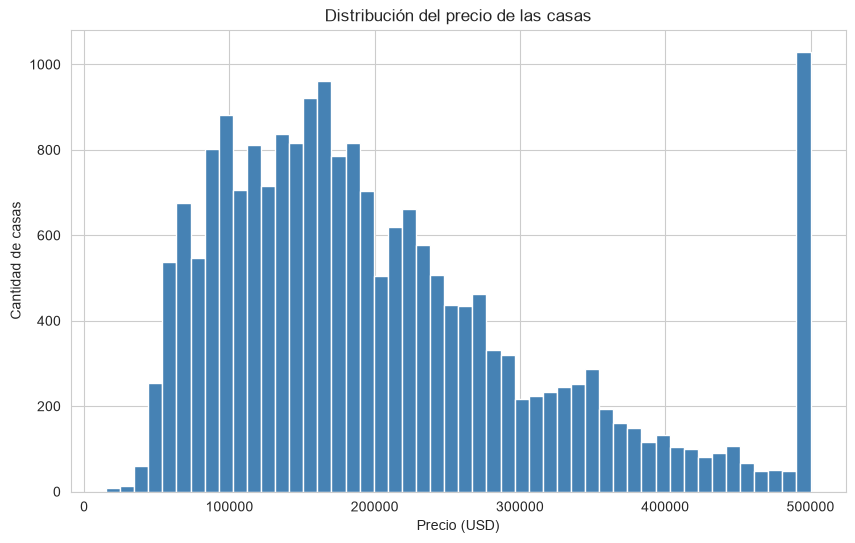

In [48]:
plt.hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución del precio de las casas')
plt.xlabel('Precio (USD)')
plt.ylabel('Cantidad de casas')
plt.show()

Mini-reporte de este gráfico:

Situación: graficamos la distribución completa de precios de casas en California.
Hallazgo: la distribución tiene sesgo hacia la derecha, con concentración de casas en el rango $100K-$200K, y una barra artificial de más de 1,000 casas en el tope de $500K por censoring del dataset.
Recomendación: al reportar "cuántas casas caras hay" o "cuál es el precio máximo", aclarar siempre esta limitación — el dataset no permite ver el verdadero techo de precios en California.

### Análisis simple: distribución de `median_income`

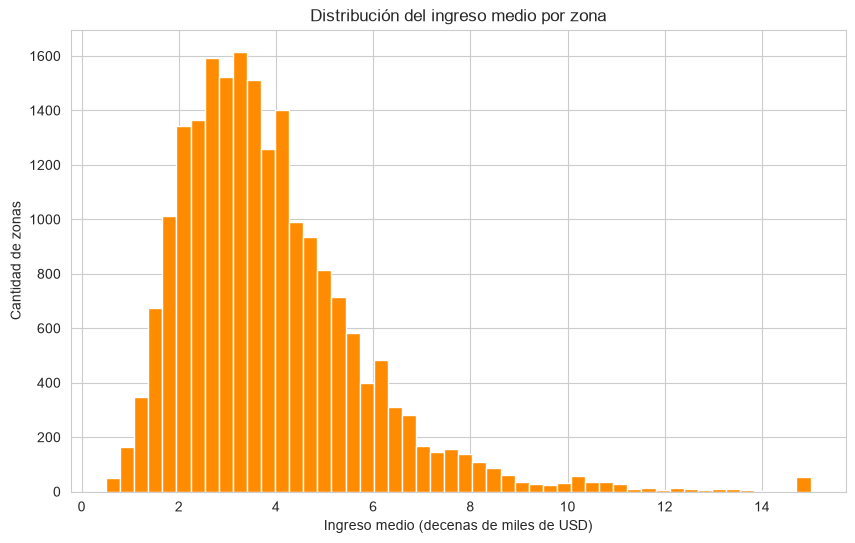

In [49]:
plt.hist(df['median_income'], bins=50, color='darkorange', edgecolor='white')
plt.title('Distribución del ingreso medio por zona')
plt.xlabel('Ingreso medio (decenas de miles de USD)')
plt.ylabel('Cantidad de zonas')
plt.show()

Mini-reporte de este gráfico:

Situación: graficamos la distribución del ingreso medio por zona.
Hallazgo: sesgo hacia la derecha (forma similar a la del precio), con un tope de censoring visible en 15 (~$150,000) — mismo patrón de recolección de datos que ya vimos en median_house_value.
Recomendación: al analizar la relación entre ingreso y precio más adelante, tener presente que ambas variables están truncadas en su extremo superior — cualquier correlación que calculemos podría estar subestimando la relación real entre "zonas muy ricas" y "casas muy caras", porque ambas puntas están cortadas por el dataset.

### Distribución segmentada: precio según cercanía al océano

Un boxplot resume la distribución de precios de cada zona en una "caja": la línea del 
medio es la mediana, el cuerpo de la caja contiene al 50% central de los precios, y los 
puntos sueltos por fuera son outliers de esa zona. Comparar varias cajas permite ver si 
el precio típico cambia según la zona.

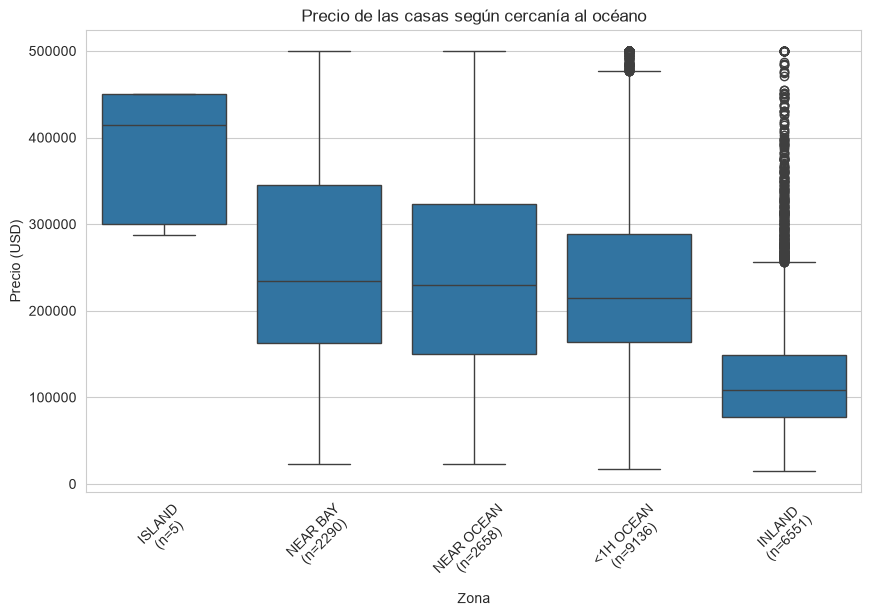

In [50]:
conteo = df['ocean_proximity'].value_counts()
orden = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index
etiquetas = [f"{cat}\n(n={conteo[cat]})" for cat in orden]

sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, order=orden)
plt.title('Precio de las casas según cercanía al océano')
plt.xlabel('Zona')
plt.ylabel('Precio (USD)')
plt.xticks(ticks=range(len(etiquetas)), labels=etiquetas, rotation=45)
plt.show()

Mini-reporte de este gráfico:

Situación: comparamos el precio de las casas segmentado por zona, corrigiendo el gráfico para no confundir por tamaño de muestra.
Hallazgo: hay una brecha grande entre zonas costeras (NEAR BAY, NEAR OCEAN, <1H OCEAN, medianas ~$210-232K) e INLAND (~$108K). ISLAND, con solo 5 casos, no es una conclusión válida pese a mostrar la mediana más alta.
Recomendación: la cercanía "de cualquier forma" al mar parece ser un factor relevante en el precio, pero no explica todo — hay que revisar si esto es un efecto directo de la ubicación o si está mediado por otra variable (por ejemplo, el ingreso de la zona, que es justo nuestra siguiente hipótesis a probar).

### Correlaciones

Para responder qué características se asocian más con el precio, calculamos la 
**correlación** entre cada variable y `median_house_value`. Este número va de -1 a 1: 
cerca de 0 significa que las dos variables no tienen relación aparente; cerca de 1 
significa que suben y bajan juntas; cerca de -1 significa que una sube cuando la otra 
baja. El siguiente mapa de calor visualiza estas correlaciones para todas las 
variables numéricas, incluyendo las zonas geográficas convertidas a 0/1.

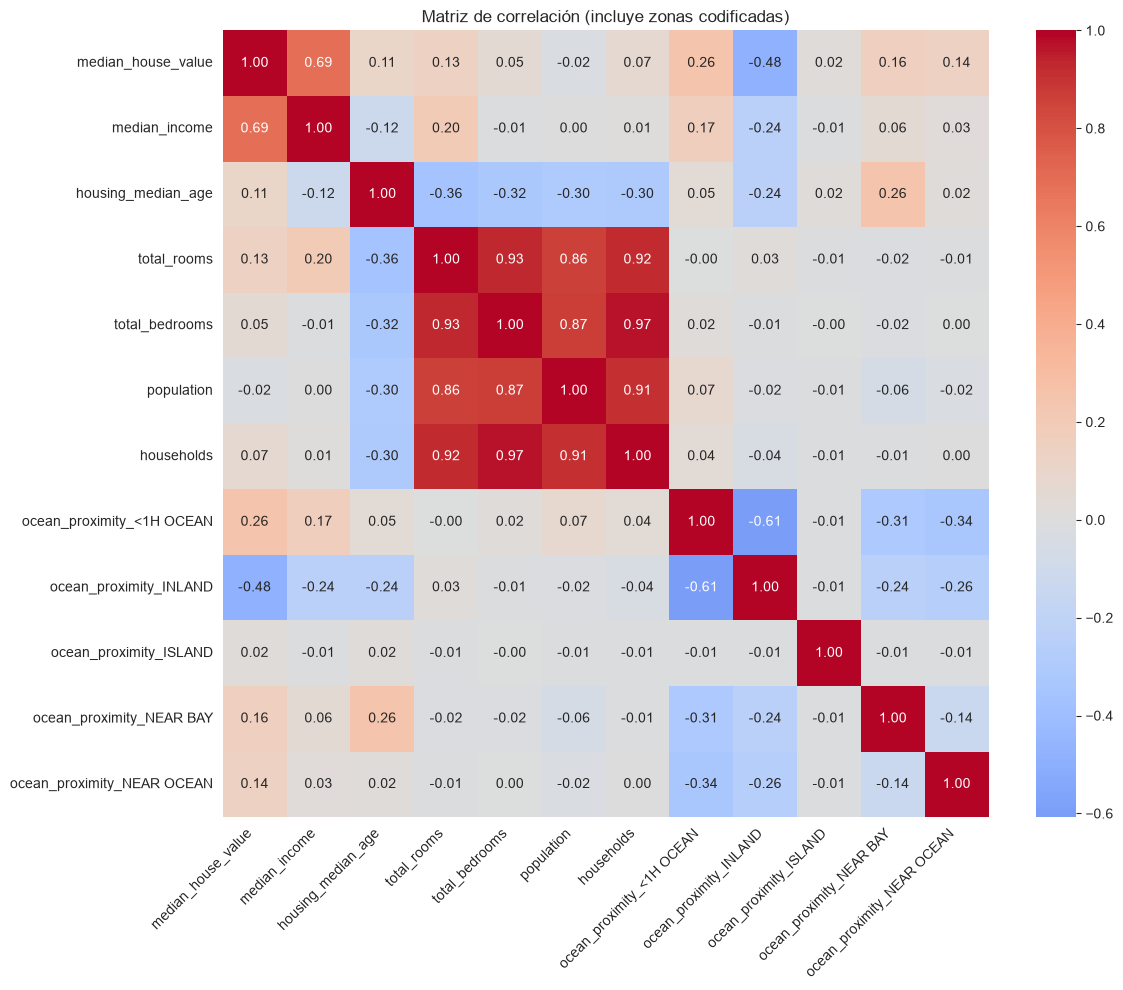

In [51]:
cols_numericas = ['median_house_value', 'median_income', 'housing_median_age',
                   'total_rooms', 'total_bedrooms', 'population', 'households']

# Sumamos las columnas de ocean_proximity ya codificadas (one-hot) en df_encoded
cols_ocean = [c for c in df_encoded.columns if c.startswith('ocean_proximity_')]
cols_para_correlacion = cols_numericas + cols_ocean

corr_matrix = df_encoded[cols_para_correlacion].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (incluye zonas codificadas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Pairplot

Esta grilla combina, en una sola imagen, un gráfico de dispersión (scatterplot) por 
cada par de variables — cada punto es una casa — y en la diagonal, la forma de la 
distribución de cada variable sola. Permite ver de un vistazo si dos variables suben 
juntas, bajan juntas, o no muestran relación clara.

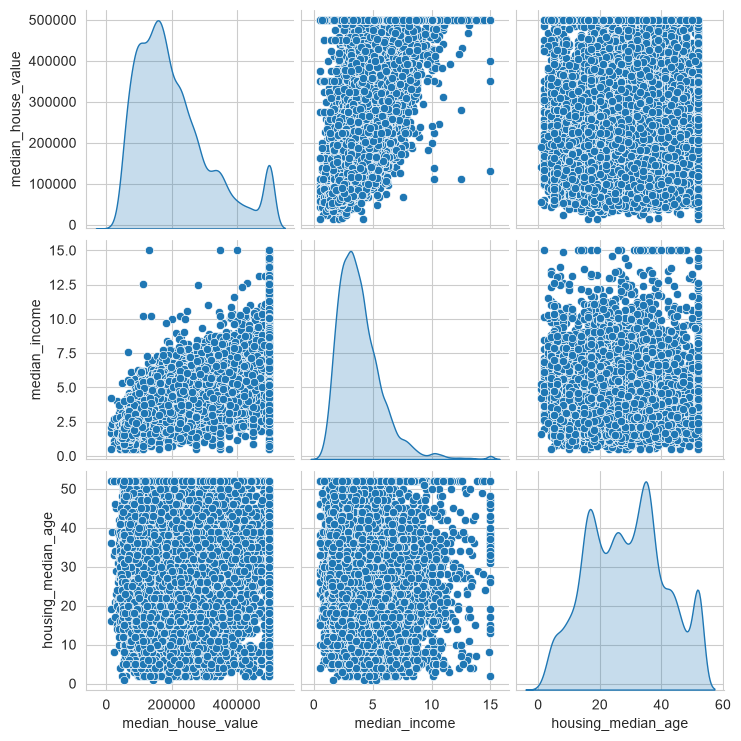

In [52]:
subset = df[['median_house_value', 'median_income', 'housing_median_age']]

sns.pairplot(subset, diag_kind='kde')
plt.show()

Mini-reporte de este pairplot:

Situación: visualizamos las relaciones entre precio, ingreso y edad de la casa con scatterplots.
Hallazgo: se confirma visualmente la relación positiva entre ingreso y precio (la nube sube de izquierda a derecha), mientras que edad de la casa no muestra ninguna tendencia clara con el precio. El pairplot también deja ver, de forma más intuitiva que el histograma, cómo el censoring de $500,001 "aplana" la parte superior de la relación ingreso-precio.
Recomendación: el ingreso sigue siendo la variable más sólida para explicar el precio, tanto por el número (0.69) como por la forma visual de la relación. La conclusión de negocio final: en California, la característica de zona más asociada al valor de una casa es el nivel de ingreso de esa zona, no su antigüedad ni (según vimos antes) exclusivamente su cercanía al mar.

## Conclusiones

- **El ingreso medio de la zona es la variable más asociada al precio** (correlación 0.69), 
  muy por encima de cualquier otra (cuartos, población, antigüedad, todas < 0.15).
- **La cercanía al mar influye, sobre todo en su ausencia:** `ocean_proximity_INLAND` 
  tiene la correlación más fuerte entre las variables de zona (-0.48) — el efecto más 
  claro no es "cerca del mar = más caro" sino "tierra adentro = notablemente más barato". 
  Entre las zonas costeras (NEAR BAY, NEAR OCEAN, <1H OCEAN) las diferencias son menores.
- **La antigüedad de la casa no tiene relación con el precio** — ni en la correlación 
  ni visualmente en el pairplot.
- **El dataset trunca algunos valores extremos:** el precio tiene un tope confirmado en 
  $500,001 (4.68% de las casas) y `housing_median_age` un tope en 52 años (6.17%) — 
  aunque, a diferencia del precio, este último no genera outliers estadísticos por IQR, 
  ya que 52 años sigue dentro de un rango considerado normal para la variable.

**Conclusión:** el ingreso de la zona explica el precio mejor que cualquier característica 
física de las casas o su ubicación exacta. Esto no implica causalidad — podría ser al 
revés, o ambas variables responder a un tercer factor no incluido en el dataset.